# ⚽ Football Intelligence Dashboard - Modeling: Predicting Player Market Value

**Goal:** Predict a player's `value_eur` from their attributes, and answer a design question from the EDA phase — does `wage_eur` actually help predict value, or is it redundant once we already know how good a player is?

We'll build **two feature sets** (with and without wage) and **two algorithms** (Linear Regression as a baseline, Random Forest as the stronger model), then compare all four.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
sns.set_palette('husl')

In [2]:
# Load our dataset (same cleaning as 02_eda.ipynb)
df = pd.read_csv("data/cleaned/fifa24_top5_leagues.csv")

outfield_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
df[outfield_stats] = df[outfield_stats].fillna(0)
df['release_clause_eur'] = df['release_clause_eur'].fillna(0)

print(f"Players: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")

Players: 3467
Missing values: 0


## Step 1: Check the Target Variable's Distribution

Before modeling, always look at how your target (`value_eur`) is distributed. Regression models like Linear Regression assume errors are roughly symmetric — if the target is heavily skewed (a few huge outliers, lots of small values), the model will focus on minimizing error for the expensive players and underperform on typical ones.

Market values for footballers are a classic case: most players are worth a few million euros, but a handful (Mbappé, Haaland) are worth 100M+. That's exactly the kind of skew we need to check for.

Skewness of value_eur: 4.27
Skewness of log1p(value_eur): 0.14


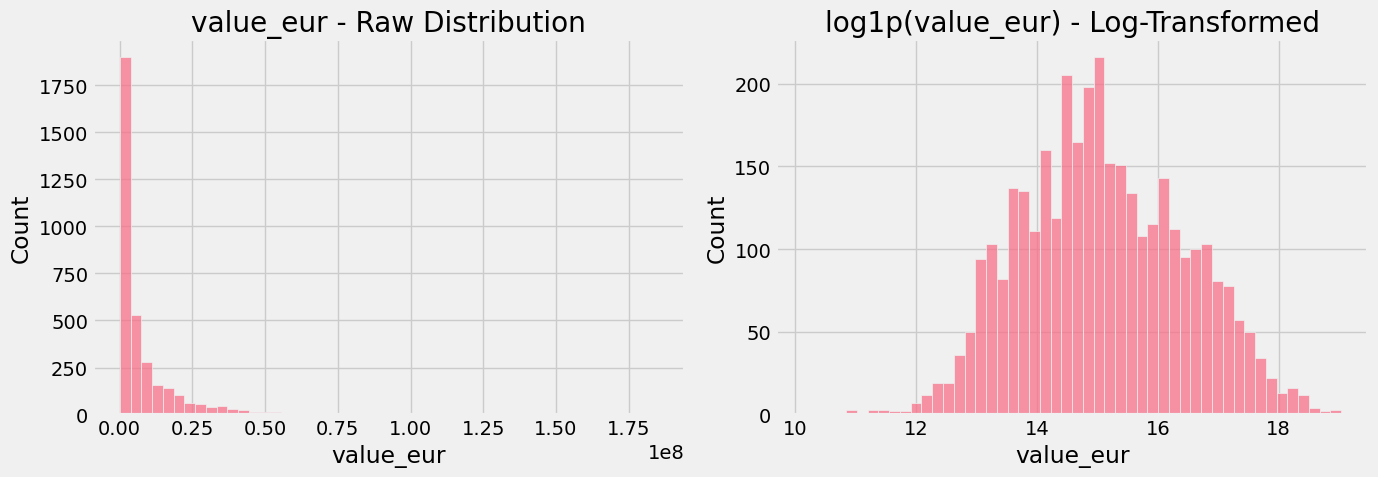

In [3]:
print(f"Skewness of value_eur: {df['value_eur'].skew():.2f}")
print(f"Skewness of log1p(value_eur): {np.log1p(df['value_eur']).skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['value_eur'], bins=50, ax=axes[0])
axes[0].set_title('value_eur - Raw Distribution')
sns.histplot(np.log1p(df['value_eur']), bins=50, ax=axes[1])
axes[1].set_title('log1p(value_eur) - Log-Transformed')
plt.tight_layout()
plt.show()

**Finding:** Raw `value_eur` has a skewness of **4.27** (heavily right-skewed — a few superstar transfers stretch the tail). After a `log1p` transform, skewness drops to **0.14**, close to a normal distribution.

**What we'll do:** Train the model to predict `log1p(value_eur)` instead of raw euros, then convert predictions back with `expm1()` for interpretable evaluation. This is standard practice whenever a target spans several orders of magnitude — money, population, income, etc.

## Step 2: Build the Two Feature Sets

Per our earlier decision, we're building **two versions** of the model:
- **Model A** — includes `wage_eur` as a feature
- **Model B** — excludes it, so value is predicted purely from playing ability and profile

Both include the on-pitch attributes from the Q3 correlation analysis, plus `position_group` (from Q7) since we already saw position affects earning power independent of skill.

In [4]:
# Position group (same mapping as Q7)
df['primary_position'] = df['player_positions'].apply(lambda x: x.split(',')[0].strip())
position_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'CDM': 'Midfielder', 'CM': 'Midfielder', 'CAM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'ST': 'Forward', 'CF': 'Forward', 'LW': 'Forward', 'RW': 'Forward', 'LF': 'Forward', 'RF': 'Forward'
}
df['position_group'] = df['primary_position'].map(position_map)

base_features = ['overall', 'potential', 'age', 'international_reputation',
                  'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
                  'weak_foot', 'skill_moves']

# One-hot encode position (drop_first avoids a redundant column)
pos_dummies = pd.get_dummies(df['position_group'], prefix='pos', drop_first=True)

X_base = pd.concat([df[base_features], pos_dummies], axis=1)
y = np.log1p(df['value_eur'])

X_model_a = pd.concat([X_base, df[['wage_eur']]], axis=1)   # with wage
X_model_b = X_base.copy()                                    # without wage

print(f"Model A features ({X_model_a.shape[1]}): {list(X_model_a.columns)}")
print(f"Model B features ({X_model_b.shape[1]}): {list(X_model_b.columns)}")

Model A features (16): ['overall', 'potential', 'age', 'international_reputation', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'weak_foot', 'skill_moves', 'pos_Forward', 'pos_Goalkeeper', 'pos_Midfielder', 'wage_eur']
Model B features (15): ['overall', 'potential', 'age', 'international_reputation', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'weak_foot', 'skill_moves', 'pos_Forward', 'pos_Goalkeeper', 'pos_Midfielder']


## Step 3: Train/Test Split

We hold out 20% of players as a **test set** the model never sees during training. This is how we check whether the model actually learned generalizable patterns, versus just memorizing the training data (**overfitting**). `random_state=42` just makes the split reproducible — you get the same split every time you run this.

In [5]:
def evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rows = []
    fitted = {}
    for model_name, model in [('Linear Regression', LinearRegression()),
                               ('Random Forest', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]:
        model.fit(X_train, y_train)
        pred_log = model.predict(X_test)

        y_test_real = np.expm1(y_test)
        pred_real = np.expm1(pred_log)

        rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
        mae = mean_absolute_error(y_test_real, pred_real)
        r2 = r2_score(y_test_real, pred_real)

        rows.append({'Feature set': label, 'Model': model_name,
                      'RMSE (EUR)': round(rmse), 'MAE (EUR)': round(mae), 'R2': round(r2, 4)})
        fitted[model_name] = model
    return rows, fitted

rows_a, models_a = evaluate(X_model_a, y, 'Model A (with wage_eur)')
rows_b, models_b = evaluate(X_model_b, y, 'Model B (without wage_eur)')

results_df = pd.DataFrame(rows_a + rows_b)
print(results_df.to_string(index=False))

               Feature set             Model  RMSE (EUR)  MAE (EUR)     R2
   Model A (with wage_eur) Linear Regression     9468126    2036706 0.6856
   Model A (with wage_eur)     Random Forest     2830770     697036 0.9719
Model B (without wage_eur) Linear Regression     8177701    1906885 0.7655
Model B (without wage_eur)     Random Forest     2676460     679177 0.9749


## 📌 Finding - Model Comparison

**Random Forest massively outperforms Linear Regression** — it explains ~97% of the variance in player value vs ~69-77% for a straight line (R²). That's expected: value doesn't move linearly with skill (a small gap in `overall` between a good and a great player often means a huge jump in value), and Random Forest captures those non-linear jumps and interactions naturally.

**Surprising result:** Model B (without `wage_eur`) is essentially tied with — even marginally better than — Model A (R² 0.9749 vs 0.9719 for Random Forest). Despite wage having the *strongest single correlation* with value back in Q3 (0.82), it adds almost nothing once the model already has skill ratings.

*RMSE = average prediction error, penalizes big misses more. MAE = average prediction error, treats all misses equally. R² = proportion of variance explained; 1.0 is a perfect fit.*

## Step 4: Feature Importance — Why Does Model B Match Model A?

Correlation (Q3) only looks at one variable at a time against the target. **Feature importance** in a Random Forest measures how much each feature actually reduces prediction error *once all the other features are already in the model* — it captures redundancy that plain correlation can't see.

Top 8 features - Model A (with wage_eur):
overall      0.796022
potential    0.142961
age          0.047107
dribbling    0.002645
pace         0.002524
shooting     0.002224
wage_eur     0.001990
passing      0.001303
dtype: float64

Top 8 features - Model B (without wage_eur):
overall      0.796520
potential    0.143380
age          0.047467
dribbling    0.002865
pace         0.002619
shooting     0.002291
passing      0.001434
defending    0.000860
dtype: float64


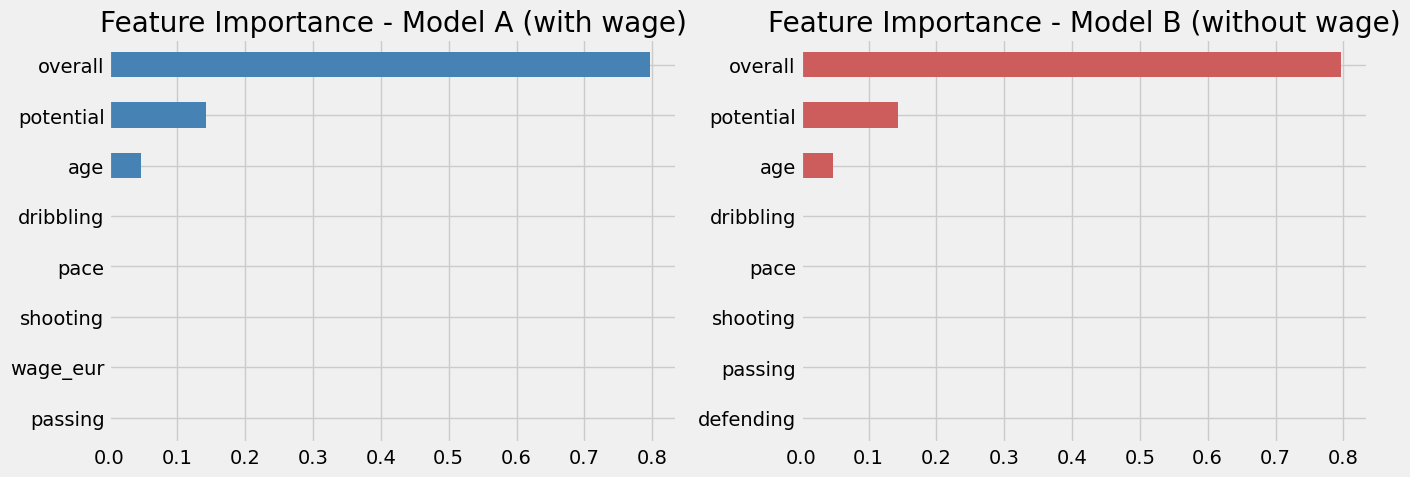

In [6]:
importance_a = pd.Series(models_a['Random Forest'].feature_importances_, index=X_model_a.columns).sort_values(ascending=False)
importance_b = pd.Series(models_b['Random Forest'].feature_importances_, index=X_model_b.columns).sort_values(ascending=False)

print("Top 8 features - Model A (with wage_eur):")
print(importance_a.head(8))
print()
print("Top 8 features - Model B (without wage_eur):")
print(importance_b.head(8))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_a.head(8).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance - Model A (with wage)')
importance_b.head(8).sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Feature Importance - Model B (without wage)')
plt.tight_layout()
plt.show()

## 📌 Finding - Feature Importance

`overall` dominates both models (~80% of importance), followed by `potential` (~14%) and `age` (~5%) — together these three account for over 98% of the model's predictive power. Every other feature, including `wage_eur` itself (importance ≈ 0.002), barely moves the needle.

**Why wage looked important in Q3 but isn't here:** correlation measures a raw, one-to-one relationship — wage is high because overall/potential are high, so it *looks* predictive on its own. But once the model already knows `overall` and `potential`, wage is redundant information — it isn't telling the model anything new. This is a classic case of **multicollinearity**: two features carrying overlapping information, where only one gets 'credit' in a multivariate model.

**Conclusion for the project:** Model B — Random Forest without `wage_eur` — is the better choice. It's simpler (one fewer input, and one that isn't always public knowledge anyway) and performs just as well. A player's market value is, in short, almost entirely explained by **how good they are right now (`overall`) and how good they could become (`potential`)**, with age acting as a moderate tiebreaker.

## Next Steps

- Save the final Model B (Random Forest) for the dashboard
- Write up this comparison in the project README as the modeling section
- (Optional) Build a small Streamlit app where a user inputs a player's stats and gets a predicted value